# Т-Интенсив. Управление рисками
## Август 2026

## Часть 1. График линейности признака по WoE.

В этой части домашки мы познакомимся с одним из основных инструментов для анализа переменных в модели логистической регрессии - графиком линейности.

Кратко идею этого графика можно сформулировать так:
 - модель *линейной* регрессии корректно применять, если значение $y$ *линейно* связано со значением $x$. Иначе линрег не подходит для данной задачи и даст неверные результаты.
 - аналогичную проверку хочется сделать и для *логистической* регрессии. Но как проверить линейность, если таргет принимает всего два значения?
 - для этого необходимо преобразовать таргет: разбить признак на бакеты и в каждом бакете посчитать WoE
 - **линейность признака по WoE для логрега – аналог линейной связи признака и таргета для линрега**

Ниже пример признака с неплохой линейностью:

![example.png](attachment:example.png)

Нам нужно обратить внимание на 3 вещи:

**1. Фиолетовые точки с доверительными интервалами.**

Это WoE для каждого отдельного бакета. В идеале нам бы хотелось, чтобы **через эти точки можно было провести прямую линию** с небольшой погрешностью. Это и означает линейную взаимосвязь с таргетом.

**2. Синяя линия**

Попытка провести прямую линию через точки. Строится с помощью логистической регрессии на одной переменной. Затем предсказания переводятся в пространство WoE, отчего и получается прямая линия.

**3. Метрики в заголовке графика**

Метрики для признака:
 - roc auc, IV измеряют разделяющую способность переменной
 - $R^2$ измеряет *линейность взаимосвязи*. Признак считается линейным, если $R^2 \geq 0.95$

Далее напишем woe-line руками, чтобы в деталях разобраться, как он строится.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as sps


In [3]:
from typing import Union, Tuple

### Шаг 0: разбиение на бакеты

In [4]:
def calc_buckets(x : Union[np.ndarray, pd.Series], n_buckets : int) -> np.ndarray:
    """Разбивает массив значений признака x на
    n_buckets бакетов"""

    x = pd.Series(x).reset_index(drop=True)
    buckets = x.rank(method="dense", pct=True) * n_buckets
    buckets = np.ceil(buckets) - 1   # np.floor дает другой результат для 5.0, 6.0 и т.д.
    buckets = np.array(buckets, dtype=np.int16)

    return buckets

In [5]:
# протестируйте calc_buckets
X_test = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
buckets_test = calc_buckets(X_test, n_buckets=4)
print(buckets_test)



[0 0 0 1 1 1 2 2 2 3 3 3]


### Шаг 1: расчет WoE по бакетам (3 балла)

Пусть $x_i \in \{ 0, 1\}^n$

$x_i$ - это вектор, состоящий из значений таргета *в одном бакете* $i$.

Для бакета можно посчитать количество единиц $B_i$ (bads, выпавшие в дефолт) и количество нулей $G_i$ (goods).

$$
B_i = \sum_{j \in x_i} \mathbb{I} \{ j = 1\}\quad G_i = \sum_{j \in x_i} \mathbb{I} \{ j = 0\}
$$

Также число бэдов и гудов можно посчитать и **для всей выборки**:

$$
% X = x_1 \cup x_2 \ldots \cup x_n
X = \{x_1,\; x_2\; \ldots\; x_n\}
$$

$$
B = \sum_{j \in X} \mathbb{I} \{ j = 1\}\quad G = \sum_{j \in X} \mathbb{I} \{ j = 0\}
$$

Тогда WoE можно посчитать как

$$
\text{WoE}_i(x) = \ln \Big ( \frac{B_i}{G_i} \Big ) - \ln \Big ( \frac{B}{G} \Big )
$$

**Задание**

Убедиться, что

$$
\text{WoE}_i(x) = \text{logit}(b_i) - \text{logit}(b)\quad  (1)
$$

где

$$
b = \frac{B}{B + G}\quad \text{logit}(p) = \ln \Big (  \frac{p}{1 - p} \Big )
$$

В дальнейшем будем считать WoE по формуле $(1)$

In [6]:
from scipy.special import logit

def woe_transform(badrate : float, offset : float) -> float:
    """Считаем WoE для бакета с данным badrate и выборки
    с данным offset."""
    woe = logit(badrate) - offset
    return woe

Здесь и далее предлагается протестироать получившиеся функции. Нужно проверить, что
 - функция не ложится с ошибкой
 - возвращает то, что ожидается

In [7]:
# протестируй woe_transform
badrate = 0.4
offset = logit(0.2)
woe = woe_transform(badrate, offset)
print("WoE:", woe)


theoretical_woe = np.log(
    (badrate / (1 - badrate)) /
    (0.2 / (1 - 0.2))
)
print("WoE вручную:", theoretical_woe)
print("Совпадает:", np.isclose(woe, theoretical_woe))


WoE: 0.9808292530117263
WoE вручную: 0.9808292530117263
Совпадает: True


### Доверительные интервалы (3 балла)

Ниже представлен шаблон функции, которая будет считать доверительный интервал к нашим вычислениям. Можно воспользоваться любым способом, который вам больше нравится. Для идей можно посмотреть различные способы подсчета доверительного интервала [здесь](https://en.wikipedia.org/wiki/Binomial_proportion_confidence_interval).

**P. S.**
Для того, чтобы построить доверительный интервал к $WoE$, можно сначала построить его для величины  $b_i = \frac{B_i}{B_i+G_i}$, а потом применить ```woe_transform```. В свою очередь величина $b_i$ является параметром распределения Бернулли, который мы можем оценить классическими методами (см. ссылку выше)

In [8]:
def woe_ci(target : np.ndarray, buckets : np.ndarray, offset : float) -> Tuple[pd.Series]:
    """Для каждого бакета вычисляем WoE и доверительный
    интервал для него."""
    # считаем бэдрейт и доверительный интервал для него (любым способом)
    data = pd.DataFrame({'target' : target, 'bucket' : buckets})
    grouped = data.groupby('bucket')['target']
    n = grouped.count()
    bads = grouped.sum()
    badrate = bads/n

    # будем строить 95% доверительный интервал, используем wilson score interval
    z = sps.norm.ppf(0.975)
    denominator = 1 + z**2/n
    center = (badrate + z**2/(2*n)) / denominator
    half_width = (z * np.sqrt( (badrate * (1-badrate))/n + (z**2)/(4*n**2))) / denominator
    upper_badrate = center + half_width
    lower_badrate = center - half_width

    # переходим от бэдрейта к woe
    woe = woe_transform(badrate, offset)
    woe_lower = woe_transform(lower_badrate, offset)
    woe_upper = woe_transform(upper_badrate, offset)

    return woe, woe_lower, woe_upper

In [9]:
# быстренько проверим, норм ли работает
target_test = np.array([
    0, 0, 1, 0, 1,
    0, 1, 1, 0, 1
])

buckets_test = np.array([
    0, 0, 0, 0, 0,
    1, 1, 1, 1, 1
])

offset_test = logit(target_test.mean())

woe, woe_lower, woe_upper = woe_ci(
    target_test,
    buckets_test,
    offset_test
)

print("WoE:", woe)
print("\nLower:", woe_lower)
print("\nUpper:", woe_upper)

WoE: bucket
0   -0.405465
1    0.405465
Name: target, dtype: float64

Lower: bucket
0   -2.015156
1   -1.204226
Name: target, dtype: float64

Upper: bucket
0    1.204226
1    2.015156
Name: target, dtype: float64


### Шаг 2: расчет линейной интерполяции (1 балл)

In [10]:
from sklearn.linear_model import LogisticRegression

def calc_line(values : np.ndarray, target : np.ndarray, mean_feature : np.ndarray, offset : float) -> np.ndarray:
    """Строим линейную интерполяцию для WoE."""

    # строим логистическую регрессию на одном признаке
    # и считаем ее предсказания в точках – mean_feature

    model = LogisticRegression()
    model.fit(
        np.asarray(values).reshape(-1, 1),
        target
    )

    # Вероятность bad для средних значений бакетов
    proba = model.predict_proba(
        np.asarray(mean_feature).reshape(-1, 1)
    )[:, 1]

    # Переводим probability -> WoE
    line = woe_transform(proba, offset)

    return line


[-4.15109827 -1.77897015  0.59315796  2.96528608  5.33741419]


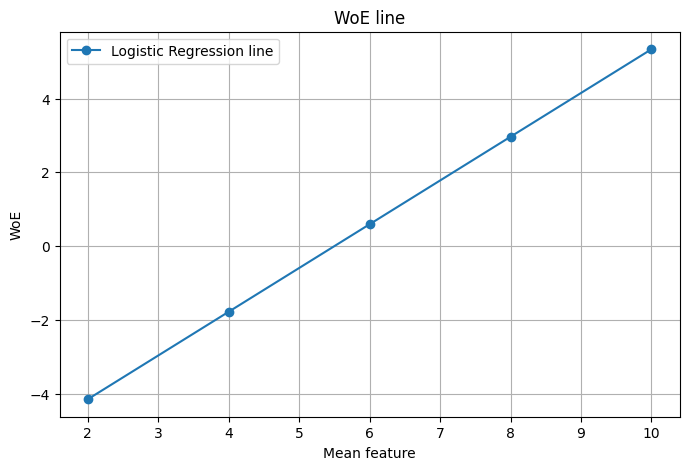

In [11]:
# протестируйте calc_line
import matplotlib.pyplot as plt
values_test = np.array([
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
])

target_test = np.array([
    0, 0, 0, 0, 0,
    1, 1, 1, 1, 1
])

mean_feature_test = np.array([
    2, 4, 6, 8, 10
])

offset_test = logit(target_test.mean())

line_test = calc_line(
    values_test,
    target_test,
    mean_feature_test,
    offset_test
)

print(line_test)
plt.figure(figsize=(8, 5))

plt.plot(
    mean_feature_test,
    line_test,
    marker='o',
    label='Logistic Regression line'
)

plt.xlabel('Mean feature')
plt.ylabel('WoE')
plt.title('WoE line')

plt.grid(True)
plt.legend()
plt.show()

### Шаг3: собираем результаты по бакетам в один словарь

In [12]:
def calc_buckets_info(values : np.ndarray, target : np.ndarray, buckets : np.ndarray) -> dict:
    """Для каждого бакета расчитывает
     - среднее значение признака
     - линейную интерполяцию в пространстве woe
     - значение woe и доверительный интервал для него"""

    data = pd.DataFrame({
        "values": values,
        "target": target,
        "bucket": buckets
    })

    grouped = data.groupby("bucket")
    mean_feature = grouped["values"].mean()
    overall_badrate = np.mean(target)
    offset = logit(overall_badrate)

    woe, woe_lower, woe_upper = woe_ci(
        target,
        buckets,
        offset
    )


    line = calc_line(
        values,
        target,
        mean_feature.values,
        offset
    )

    # Plotly в make_figure ожидает размеры error bars, поэтому превращаем границы в расстояния от центральной точки
    woe_lower_error = woe.values - woe_lower.values
    woe_upper_error = woe_upper.values - woe.values

    buckets_info = {
        "mean_feature": mean_feature.values,
        "line": line,
        "woe": woe.values,
        "woe_lower": woe_lower_error,
        "woe_upper": woe_upper_error
    }

    return buckets_info


In [13]:
# протестируйте calc_buckets_info
np.random.seed(89)

sample_size = 1000

target_test = np.random.binomial(
    1,
    0.5,
    sample_size
)

values_test = np.random.normal(
    target_test,
    1
)

buckets_test = calc_buckets(
    values_test,
    5
)

buckets_info_test = calc_buckets_info(
    values_test,
    target_test,
    buckets_test
)

print(buckets_info_test)

{'mean_feature': array([-1.08607132, -0.14841327,  0.4787405 ,  1.1041745 ,  2.1320892 ]), 'line': array([-1.77781876, -0.71704511, -0.00754532,  0.70000891,  1.86289002]), 'woe': array([-1.83129031, -0.56972799, -0.05600568,  0.71488717,  1.71860071]), 'woe_lower': array([0.39680249, 0.2868874 , 0.27635596, 0.29482733, 0.38573484]), 'woe_upper': array([0.39680249, 0.2868874 , 0.27635596, 0.29482733, 0.38573484])}


### Шаг 4: считаем метрики признака (3 балла)

Рассчитаем также несколько метрик, чтобы судить о качестве признака не только по картинкам.

Приведем формулу для IV:

$$
\text{IV}(x) = \sum_{i = 1}^{n}\Big ( \frac{B_i}{B} - \frac{G_i}{G} \Big ) \times \text{WoE}_i
$$

**Вопрос:** зачем считать ранжирующую силу признака двумя способами? Какую дополнительную информацию может дать IV относительно roc auc?

Ответ: ROC AUC оценивает, насколько хорошо признак ранжирует наблюдения двух классов; IV учитывает не только порядок наблюдений, но и то, насколько отличаются распределения goods и bads по бакетам. IV «ловит» немонотонности п о WoE и позволяет понимать, когда фича разделяет риски, но плохо ранжирует наблюдения


In [14]:
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LinearRegression


def calc_plot_title(
        values : np.ndarray,
        target : np.ndarray,
        buckets : np.ndarray
    ) -> str:

    values = np.asarray(values)
    target = np.asarray(target)
    buckets = np.asarray(buckets)

    data = pd.DataFrame({'values' : values, 'target' : target, 'bucket' : buckets})
    grouped = data.groupby('bucket')

    # 1. AUC
    auc = roc_auc_score(target, values)

    # 2. WOE и IV
    total_bads = np.sum(target)
    total_goods = len(target) - total_bads

    bucket_count = grouped.count()['target'] # или просто .size()
    bucket_bads = grouped['target'].sum()
    bucket_goods = bucket_count - bucket_bads

    # Добавляем epsilon, чтобы избежать log(0)
    epsilon = 1e-10
    bucket_bads_smoothed = bucket_bads + epsilon
    bucket_goods_smoothed = bucket_goods + epsilon

    bad_share = bucket_bads / total_bads
    good_share = bucket_goods / total_goods

    # Рассчитываем badrate с учетом сглаживания для WOE
    badrate_smoothed = bucket_bads_smoothed / (bucket_bads_smoothed + bucket_goods_smoothed)
    offset = logit(target.mean())

    woe = woe_transform(badrate_smoothed, offset)

    # IV считается с использованием оригинальных долей для сохранения интерпретации
    IV = np.sum((bad_share - good_share) * woe)

    # 3. Взвешенный R^2
    mean_feature = grouped['values'].mean()
    weights = bucket_count.values

    X = mean_feature.values.reshape(-1, 1)
    Y = woe.values

    model = LinearRegression()
    model.fit(X, Y, sample_weight=weights)

    R_sqr = model.score(X, Y, sample_weight=weights)

    plot_title = (
        f"AUC = {auc:.3f} "
        f"IV = {IV:.3f} "
        f"R_sqr = {R_sqr:.3f} "
    )

    return plot_title

In [15]:
plot_title_test = calc_plot_title(
    values_test,
    target_test,
    buckets_test
)

print(plot_title_test)

AUC = 0.788 IV = 1.171 R_sqr = 0.995 


### Шаг 5: собираем все в одну функцию и строим график

In [16]:
# в этот код можно не въезжать :)
import plotly.graph_objects as go

def make_figure(buckets_info : dict, plot_title : str) -> go.Figure:
    """Строит график линейности."""
    fig = go.Figure()

    # общие настройки
    title = dict(
        text=plot_title,
        y=0.95,
        x=0.5,
        font=dict(size=12),
        xanchor="center",
        yanchor="top"
    )
    margin = go.layout.Margin(
        l=50,
        r=50,
        b=50,
        t=60
    )

    fig.add_trace(
        go.Scatter(
            x=buckets_info["mean_feature"],
            y=buckets_info["line"],
            mode='lines',
            name="interpolation_line",
            showlegend=False
        )
    )

    fig.add_trace(
        go.Scatter(
            x=buckets_info["mean_feature"],
            y=buckets_info["woe"],
            line=dict(
                color='firebrick',
                width=1,
                dash='dot'
            ),
            error_y=dict(
                type='data',
                symmetric=False,
                array=buckets_info["woe_upper"],
                arrayminus=buckets_info["woe_lower"]
            ),
            name="WoE",
            showlegend=False)
    )

    fig.update_layout(
        width=1000,
        height=450,
        xaxis_title=dict(
            text='Feature value',
            font=dict(size=12)
        ),
        yaxis_title=dict(
            text="WoE",
            font=dict(size=12)
        ),
        title=title,
        margin=margin
    )

    return fig

In [17]:
def woe_line(
        values : np.ndarray,
        target : np.ndarray,
        n_buckets : int
    ) -> go.Figure:
    """График линейности переменной по WoE."""
    buckets : np.ndarray = calc_buckets(values, n_buckets)
    buckets_info : pd.DataFrame = calc_buckets_info(values, target, buckets)
    plot_title : str = calc_plot_title(values, target, buckets)
    fig = make_figure(buckets_info, plot_title)
    return fig

Чтобы протестировать реализацию, сгенерируем синтетические данные:

In [18]:
sample_size = int(1e4)
noise_std = 1.

df = pd.DataFrame()
y = np.array(sample_size // 2 * [0] + sample_size // 2 * [1])
df['target']  = y

np.random.seed(89)
x = np.concatenate([sps.norm(0, noise_std).rvs(size = sample_size // 2), sps.norm(1, noise_std).rvs(size = sample_size // 2)])
df['feature'] = x

<Axes: xlabel='feature', ylabel='Count'>

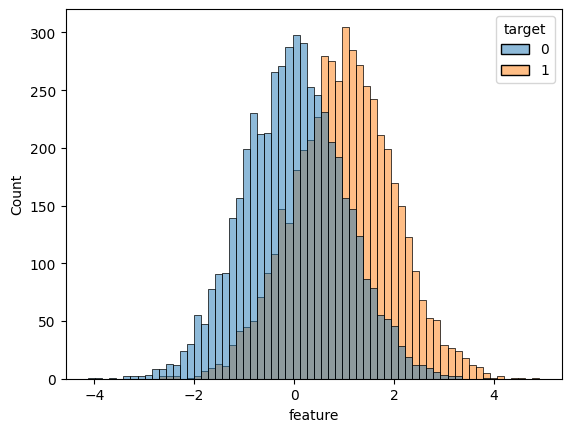

In [19]:
sns.histplot(df, x = 'feature', hue = 'target')

In [20]:
# запустите после того, как реализуете все функции
woe_line(values=x, target=y, n_buckets=5)

### Эксперименты (2 балла)

#### №1

Как будут меняться график, метрики разделяющей способности и $R^2$ при изменении дисперсии шума (параметр `noise_std`)?

In [21]:
noise_stds = [0.25, 0.5, 1.0, 1.5, 2.0]

results = []

for noise_std in noise_stds:

    np.random.seed(89)

    x_exp = np.concatenate([
        sps.norm(
            0,
            noise_std
        ).rvs(size=sample_size // 2),

        sps.norm(
            1,
            noise_std
        ).rvs(size=sample_size // 2)
    ])

    buckets_exp = calc_buckets(
        x_exp,
        5
    )

    title = calc_plot_title(
        x_exp,
        y,
        buckets_exp
    )

    results.append({
        "noise_std": noise_std,
        "metrics": title
    })

pd.DataFrame(results)

,noise_std,metrics
0,0.25,AUC = 0.997 IV = 29.284 R_sqr = 0.891
1,0.50,AUC = 0.920 IV = 3.528 R_sqr = 1.000
2,1.00,AUC = 0.760 IV = 0.882 R_sqr = 0.999
3,1.50,AUC = 0.681 IV = 0.400 R_sqr = 0.998
4,2.00,AUC = 0.638 IV = 0.226 R_sqr = 0.995


При увеличении дисперсии шума распределения признака для двух классов сильнее перекрываются. Поэтому разделяющая способность признака снижается: уменьшаются ROC AUC и IV. Точки WoE становятся более шумными, а доверительные интервалы увеличиваются.

#### №2

Запустите функцию с `values=x ** 2`. Как по графику определить эту ситуацию? Что нужно делать в таком случае?

In [27]:
woe_line(
    values=x ** 2,
    target=y,
    n_buckets=5
)

После возведения признака в квадрат зависимость становится нелинейной и теряется информация о знаке исходного признака. На WoE-графике это проявляется в виде изгиба/не монотонной зависимости. В таком случае необходимо подобрать другое преобразование или добавить признаки, сохраняющие потерянную информацию.

#### №3

Запустите функцию с `values=np.exp(x)`. Как по графику определить эту ситуацию? Что нужно делать в таком случае?

In [22]:
woe_line(
    values=np.exp(x),
    target=y,
    n_buckets=5
)

В следствие монотонности преобразования ROC-AUC вообще не упал, хотя в теории мог немного снизиться. Но, очевидно, линейная свзяь между признаками и WoE теряется. В этом случае явно видно, что график напоминает логарифм, для исправления ситуации можно применить обратное преобразование, то есть логарифм.

## Часть 2. Строим ЛогРег. (8 баллов)

В этом пунтке попробуем применить все наши навыки

Скачайте датасет на EDU. Пароль вы найдете в телеграм-канале курса, в посте с анонсом домашки.

In [34]:
df = pd.read_csv('logreg_hw_5.csv', index_col=0)
df = df.dropna(subset=['d4p12'])
df

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,d4p12
0,-1.444709,3.554779,1.308371,-0.000119,0.029628,3.829880,1,8.825418,3.829880,11.565953,-513.014565,-1.072893,7.936545,0.047069,B,1
1,1.132531,-0.207661,-2.142882,0.062686,0.859062,6.189545,1,3.453220,6.189545,4.935665,-39.351891,3.409855,17.015210,0.029288,A,0
2,1.268781,-0.243999,10000.000000,0.339225,0.614599,12.503629,1,-10.116061,12.503629,6.234414,-4.993050,3.121126,4.878602,0.237255,A,0
3,-1.278475,-2.579890,5.050763,-0.938956,0.090461,-1.080041,1,6.780814,-1.080041,2.682539,-509.273095,-1.242741,20.293025,0.907788,B,0
4,3.507807,0.152661,-8.905005,0.067646,0.216199,1.367184,1,-10.638134,1.367184,6.881602,-2.034797,2.814972,7.352399,0.276854,A,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-3.061422,-0.163832,4.812768,-0.949937,0.224437,5.263508,1,-9.959913,5.263508,5.294558,-524.265291,-1.648415,5.410059,0.855190,B,0
99996,0.222451,-0.273191,0.380895,0.860607,0.950708,0.581767,1,-1.645952,0.581767,5.571499,-13.499956,3.386865,92.903615,0.006668,A,1
99997,1.078498,0.339526,-5.184847,0.242072,0.854085,0.995075,1,-5.565932,0.995075,-0.433263,3.928387,3.290285,1.233853,0.160933,A,1
99998,-1.431421,-0.605388,2.466023,-0.056519,0.736255,2.980562,1,-4.517188,2.980562,10.812813,-507.593408,-1.398568,1904.246147,0.077164,B,1


Как вы выдите, ```feature_1, ..., feature_14``` - числа
```feature_15``` - категориальная фича

### Задание 0. EDA.

Как бы вы начали знакомиться с данными до построения модели? Постройте 3-5 графиков / таблиц, чтобы передать основную информацию о датасете.

In [35]:
print('Информация о данных')
df.info()

print('Проверка пропусков')
print(df.isnull().sum())

print('Распределение целевой переменной')
print(df['d4p12'].value_counts(normalize=True))

Информация о данных
<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   feature_1   100000 non-null  float64
 1   feature_2   100000 non-null  float64
 2   feature_3   100000 non-null  float64
 3   feature_4   100000 non-null  float64
 4   feature_5   100000 non-null  float64
 5   feature_6   100000 non-null  float64
 6   feature_7   100000 non-null  int64  
 7   feature_8   100000 non-null  float64
 8   feature_9   100000 non-null  float64
 9   feature_10  100000 non-null  float64
 10  feature_11  100000 non-null  float64
 11  feature_12  100000 non-null  float64
 12  feature_13  100000 non-null  float64
 13  feature_14  100000 non-null  float64
 14  feature_15  100000 non-null  object 
 15  d4p12       100000 non-null  int64  
dtypes: float64(13), int64(2), object(1)
memory usage: 13.0+ MB
Проверка пропусков
feature_1     0
feature_2     0
feat

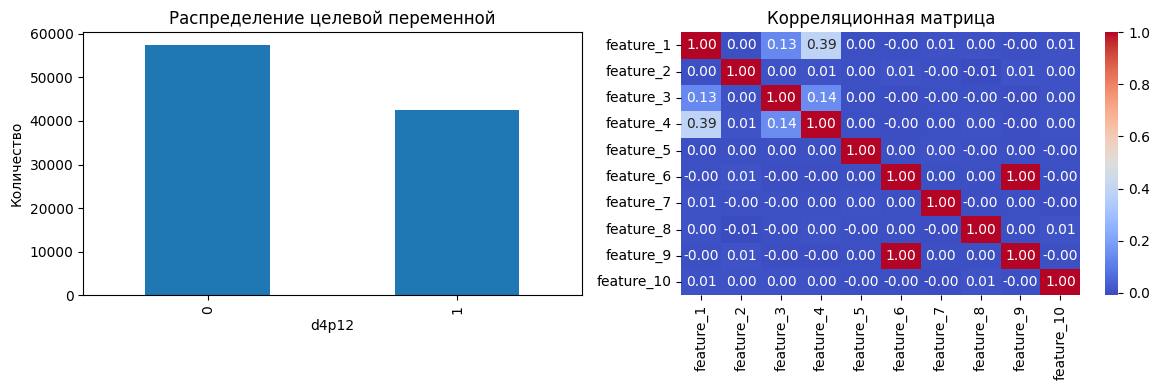

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Распределение таргета
df['d4p12'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Распределение целевой переменной')
axes[0].set_xlabel('d4p12')
axes[0].set_ylabel('Количество')

# Корреляционная матрица для числовых признаков (первые 10)
numeric_cols = df.select_dtypes(include=[np.number]).columns[:10]
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Корреляционная матрица')

plt.tight_layout()
plt.show()


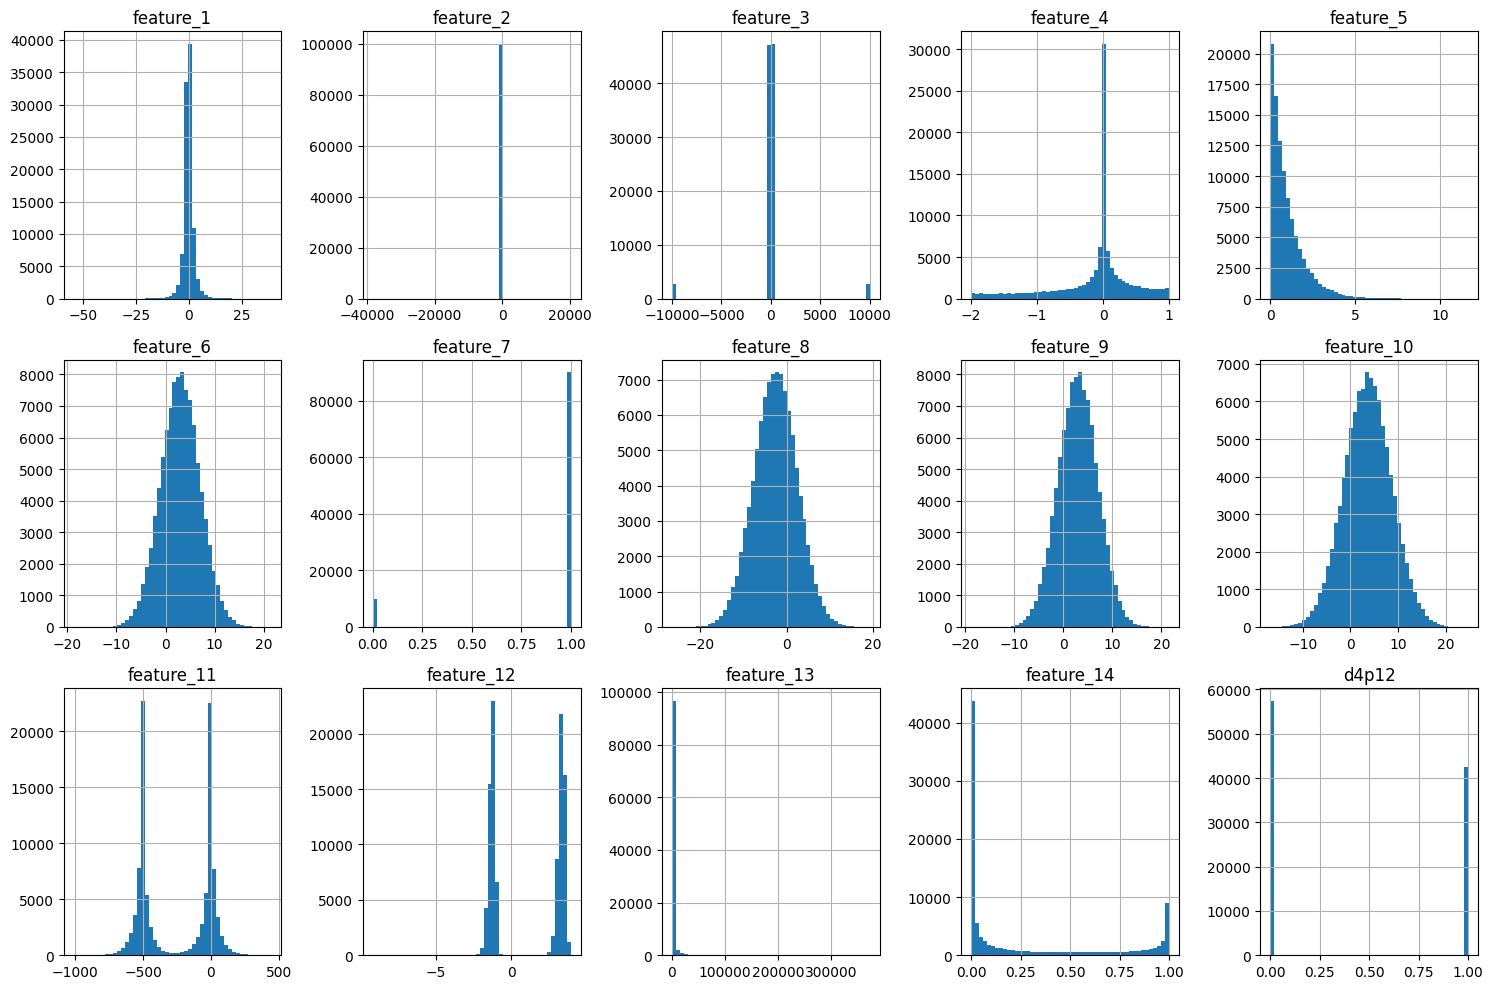

Анализ категориальной переменной feature_15
feature_15
B    50106
A    49894
Name: count, dtype: int64
Дефолт по категориям
feature_15
A    0.503487
B    0.347583
Name: d4p12, dtype: float64


In [37]:
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()

numeric_cols = df.select_dtypes(include=[np.number]).columns[:15]
for i, col in enumerate(numeric_cols):
    if i < len(axes):
        df[col].hist(bins=50, ax=axes[i])
        axes[i].set_title(col)
        axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

print('Анализ категориальной переменной feature_15')
print(df['feature_15'].value_counts())
print('Дефолт по категориям')
print(df.groupby('feature_15')['d4p12'].mean().sort_values(ascending=False))

### Задание 1. Бейзлайн.

Попробуйте построить ЛогРег только на числовых данных. Для этого разбейте датасет на трейн и тест (80/20). Перед обучением логрега стандартизуйте переменные. Это может быть полезно для численной устойчивости алгоритмов оптимизации.

Для этой модели и всех дальнейших:

1. Получилась ли модель линейной? Постройте график линейности на трейне и на тесте и сделайте вывод.
2. Расчитайте AUC и IV на трейне и на тесте. Что можно сказать о переобучении?

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

feature_cols = [col for col in df.columns if col not in ['d4p12', 'feature_15']]
X = df.drop(columns=['feature_15', 'd4p12'])
y = df['d4p12']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Доля дефолта в train: {y_train.mean():.3f}")
print(f"Доля дефолта в test: {y_test.mean():.3f}")


Размер обучающей выборки: (80000, 14)
Размер тестовой выборки: (20000, 14)
Доля дефолта в train: 0.425
Доля дефолта в test: 0.425


In [40]:
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])


numeric_pipeline.fit(X_train, y_train)

y_train_pred_proba = numeric_pipeline.predict_proba(X_train)[:, 1]
y_test_pred_proba = numeric_pipeline.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_pred_proba)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

print("Результаты базовой модели (только числовые)")
print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC:  {test_auc:.4f}")
print(f"Разница:   {train_auc - test_auc:.4f}")

=== Результаты базовой модели (только числовые) ===
Train AUC: 0.7055
Test AUC:  0.7143
Разница:   -0.0089


In [55]:
train_pred = numeric_pipeline.predict_proba(X_train)[:, 1]
test_pred = numeric_pipeline.predict_proba(X_test)[:, 1]

print("График линейности на TRAIN")
fig_train = woe_line(
    values=train_pred,
    target=y_train.values,
    n_buckets=10
)
fig_train.show()

print("График линейности на TEST")
fig_test = woe_line(
    values=test_pred,
    target=y_test.values,
    n_buckets=10
)
fig_test.show()

График линейности на TRAIN


График линейности на TEST


### Задание 2. Добавляем категориальную переменную.

Повторите задание 1, включив в модель категориальную переменную (например, с помощью one-hot encoding).

Улучшилось ли качество?

In [56]:
from sklearn.compose import ColumnTransformer
feature_cols_with_cat = [col for col in df.columns if col != 'd4p12']
X_with_cat = df[feature_cols_with_cat]

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_with_cat, y, test_size=0.2, random_state=42, stratify=y
)

numeric_cols_cat = [col for col in feature_cols_with_cat if col != 'feature_15']


preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols_cat),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), ['feature_15'])
])

model_with_cat = Pipeline([
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])

model_with_cat.fit(X_train_cat, y_train_cat)

y_train_pred_cat = model_with_cat.predict_proba(X_train_cat)[:, 1]
y_test_pred_cat = model_with_cat.predict_proba(X_test_cat)[:, 1]

train_auc_cat = roc_auc_score(y_train_cat, y_train_pred_cat)
test_auc_cat = roc_auc_score(y_test_cat, y_test_pred_cat)

print("Результаты модели с категориальной переменной")
print(f"Train AUC: {train_auc_cat:.4f}")
print(f"Test AUC:  {test_auc_cat:.4f}")
print(f"Разница:   {train_auc_cat - test_auc_cat:.4f}")
print(f"\nУлучшение относительно базовой модели: {test_auc_cat - test_auc:.4f}")

Результаты модели с категориальной переменной
Train AUC: 0.8603
Test AUC:  0.8597
Разница:   0.0005

Улучшение относительно базовой модели: 0.1454


### Задание 3. Линеаризация переменных.

На самом деле, категориальные переменные можно учитывать в моделях совсем по-другому. С их помощью можно выделить в модели сегменты. Каждому сегменту соответствует своя модель (в нашем случае логрег).

Примером такой сегментации может стать сегментация по наличию кредитной истории. В этом случае на разных сегментах будут не просто отдельные модели, но и даже разный изначальный набор признаков. Другое свидетельство удачной сегментации – разный характер зависимости признаков и целевой переменной. Это можно увидеть на графике линейности признака по WoE. Этим мы и займемся далее.

Используйте переменную 15 для сегментации модели. На каждом из двух сегментов линеаризуйте переменные. Для этого приложите:
 - график линейности переменной до преобразования
 - график после подобранного преобразования

Помимо этого:
 - попробуйте линеаризовать какие-нибудь 2 переменные *на всей выборке*. Получилось ли у вас что-то? Постройте график.
 - по графику линейности определите шумовые (либо слабоинформативные) переменные. В конце задания приложите их список.

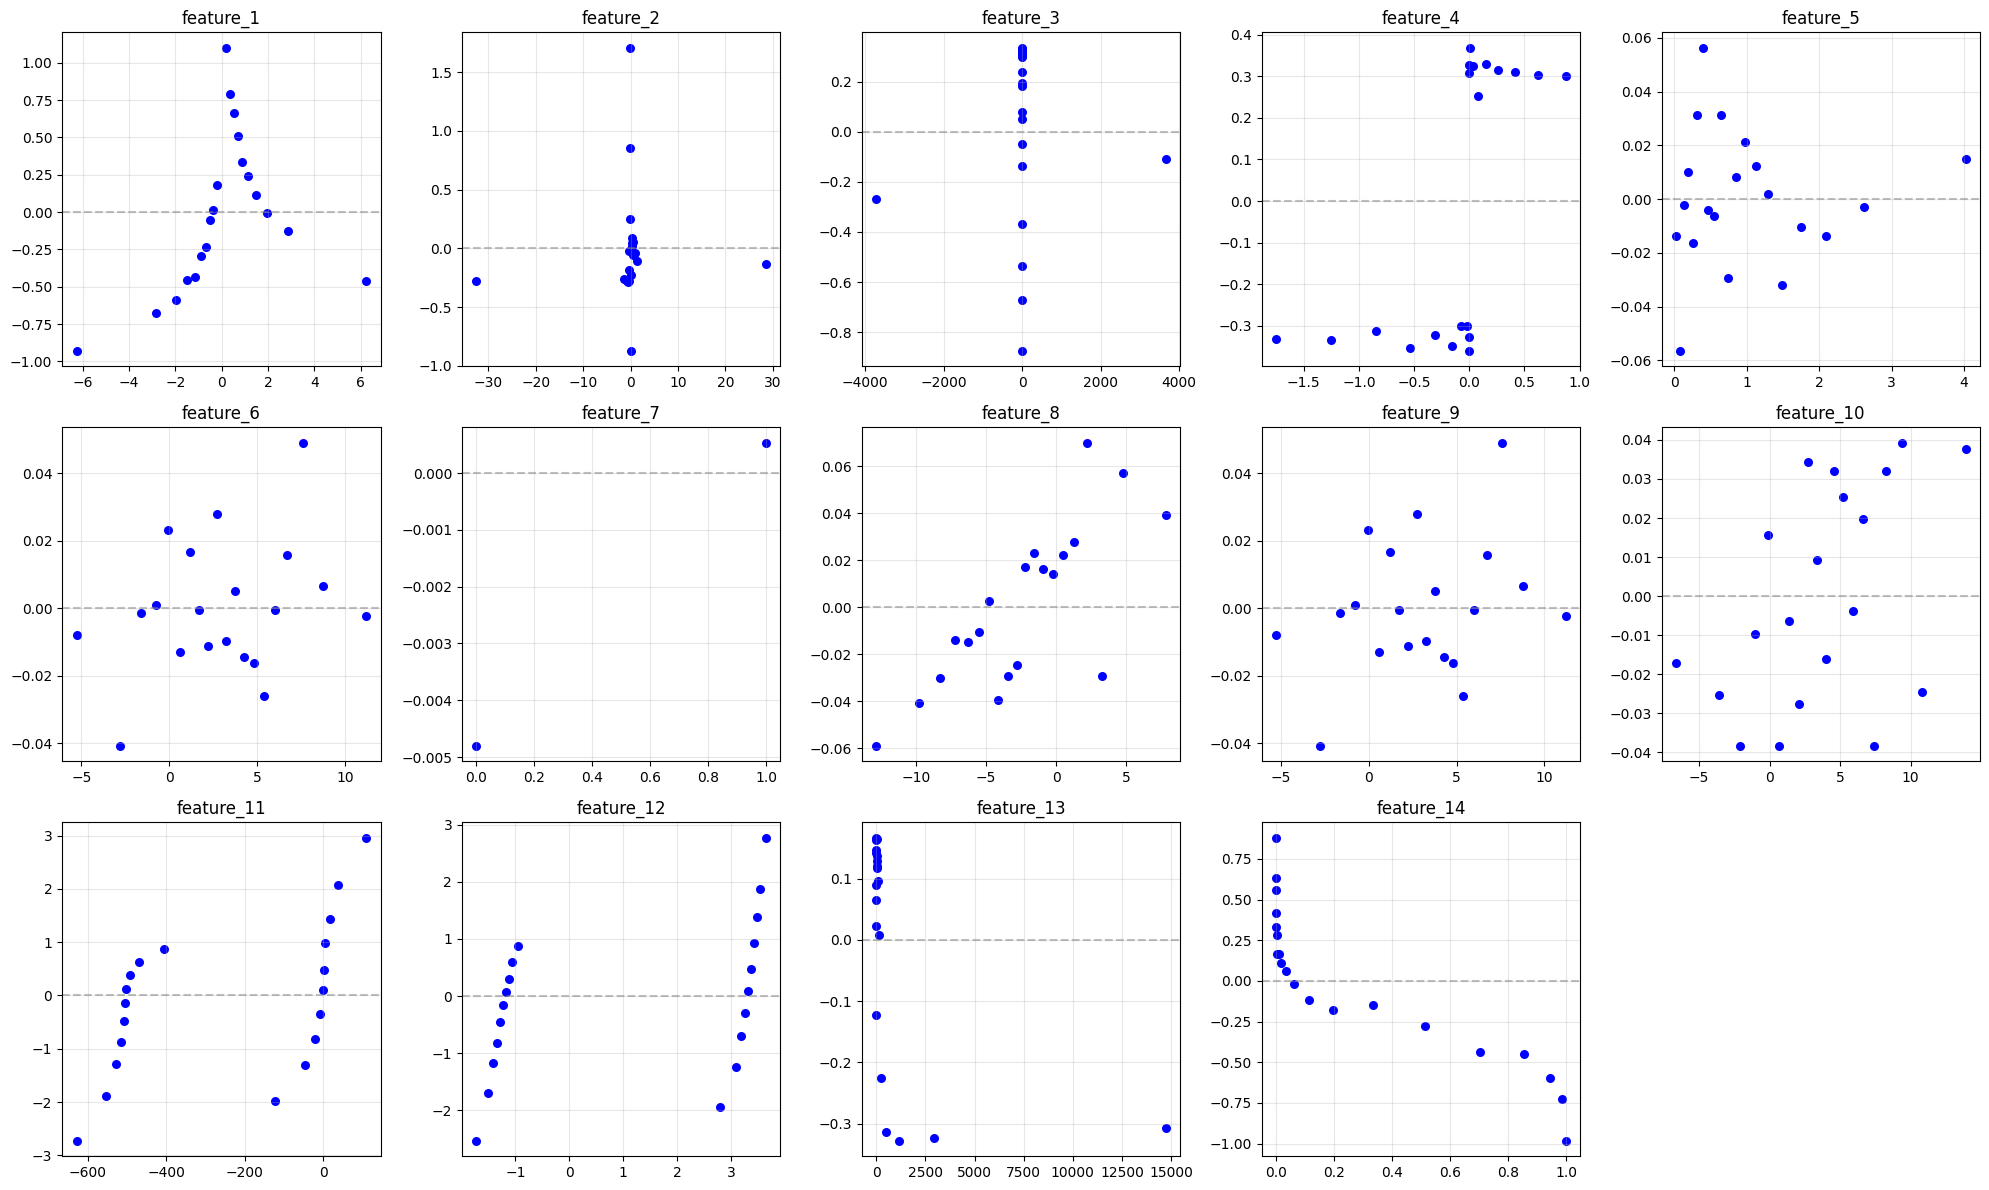

In [44]:
features_to_check = [f'feature_{i}' for i in range(1, 15)]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, feat in enumerate(features_to_check):
    vals = df[feat].values
    target = df['d4p12'].values

    # Считаем WoE по бакетам вручную
    buckets = calc_buckets(vals, 20)
    data = pd.DataFrame({'values': vals, 'target': target, 'bucket': buckets})
    grouped = data.groupby('bucket')
    mean_feature = grouped['values'].mean()
    offset = logit(target.mean())

    # WOE
    total_bads = target.sum()
    total_goods = len(target) - total_bads
    bucket_count = grouped.size()
    bucket_bads = grouped['target'].sum()
    bucket_goods = bucket_count - bucket_bads

    smoothing = 0.5
    badrate_smoothed = (bucket_bads + smoothing) / (bucket_count + 2*smoothing)
    woe = woe_transform(badrate_smoothed, offset)

    # График
    axes[i].scatter(mean_feature, woe, color='blue', s=30)
    axes[i].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[i].set_title(f'{feat}')
    axes[i].grid(True, alpha=0.3)

# Убираем лишние пустые графики (если есть)
for j in range(len(features_to_check), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [47]:
feature_importance = {}

for col in numeric_cols:  # feature_1 ... feature_14
    try:
        auc = roc_auc_score(df['d4p12'], df[col])
        feature_importance[col] = auc
    except:
        pass

# Сортируем по убыванию AUC
sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

print('Топ самых информативных переменных')
for feat, auc in sorted_features[:10]:
    print(f"{feat}: {auc:.4f}")

print("Шумовые/слабоинформативные переменные (AUC < 0.52)")
noise_features = [feat for feat, auc in sorted_features if auc < 0.52]
for feat in noise_features:
    print(f"{feat}: {feature_importance[feat]:.4f}")

Топ самых информативных переменных
d4p12: 1.0000
feature_11: 0.7223
feature_12: 0.7151
feature_4: 0.5789
feature_1: 0.5697
feature_2: 0.5144
feature_8: 0.5073
feature_10: 0.5037
feature_6: 0.5015
feature_9: 0.5015
Шумовые/слабоинформативные переменные (AUC < 0.52)
feature_2: 0.5144
feature_8: 0.5073
feature_10: 0.5037
feature_6: 0.5015
feature_9: 0.5015
feature_5: 0.5005
feature_7: 0.5002
feature_3: 0.4742
feature_13: 0.4676
feature_14: 0.3732


In [50]:
# Вот здесь честно пошло гпт, я не очень разобрался с тем, как именно подбирать преобразования и для каких вообще переменных
# Логика простая:
# 1. Если значения > 0 и распределение скошено -> log
# 2. Если распределение симметричное -> квадрат/куб для усиления нелинейности
# 3. Если есть отрицательные -> sign_square

def choose_transformation(series, col_name):
    """Выбирает преобразование на основе распределения"""
    min_val = series.min()
    max_val = series.max()
    skew = series.skew()

    # Проверяем на наличие нулей/отрицательных для log
    has_zero_or_negative = (series <= 0).any()

    # Если все значения положительные и сильный перекос -> log
    if not has_zero_or_negative and abs(skew) > 1.5:
        return f"np.log({col_name})", np.log(series)

    # Если есть отрицательные и сильный перекос -> sign_square
    if has_zero_or_negative and abs(skew) > 1.0:
        return f"sign_square({col_name})", sign_square(series)

    # Если значения симметричные -> квадрат (усиление)
    if abs(skew) < 0.5:
        return f"{col_name}**2", series**2

    # По умолчанию оставляем как есть
    return f"{col_name}", series

# Применяем ко всем фичам
transformations = {}
for i in range(1, 15):
    col = f'feature_{i}'
    trans_name, trans_vals = choose_transformation(df[col], col)
    transformations[col] = {'name': trans_name, 'values': trans_vals}

    print(f"{col}: {trans_name} (skew={df[col].skew():.2f})")

feature_1: feature_1**2 (skew=-0.36)
feature_2: sign_square(feature_2) (skew=-107.50)
feature_3: feature_3**2 (skew=-0.04)
feature_4: sign_square(feature_4) (skew=-1.14)
feature_5: np.log(feature_5) (skew=1.99)
feature_6: feature_6**2 (skew=-0.01)
feature_7: sign_square(feature_7) (skew=-2.67)
feature_8: feature_8**2 (skew=0.00)
feature_9: feature_9**2 (skew=-0.01)
feature_10: feature_10**2 (skew=-0.01)
feature_11: feature_11**2 (skew=0.00)
feature_12: feature_12**2 (skew=0.00)
feature_13: np.log(feature_13) (skew=15.90)
feature_14: feature_14 (skew=0.93)


In [53]:
# получили, что преобразования гпт оказались вообще бесполезными)))
print("=== Сравнение AUC до и после преобразований ===")
print("-" * 60)
print(f"{'Feature':<15} {'Original AUC':<15} {'Transformed AUC':<15} {'Improvement':<12}")
print("-" * 60)

for i in range(1, 15):
    col = f'feature_{i}'
    orig_auc = roc_auc_score(df['d4p12'], df[col])
    trans_auc = roc_auc_score(df['d4p12'], transformations[col]['values'])
    impr = trans_auc - orig_auc

    print(f"{col:<15} {orig_auc:.4f}          {trans_auc:.4f}          {impr:+.4f}")

=== Сравнение AUC до и после преобразований ===
------------------------------------------------------------
Feature         Original AUC    Transformed AUC Improvement 
------------------------------------------------------------
feature_1       0.5697          0.3947          -0.1750
feature_2       0.5144          0.5144          +0.0000
feature_3       0.4742          0.4288          -0.0453
feature_4       0.5789          0.5789          +0.0000
feature_5       0.5005          0.5005          +0.0000
feature_6       0.5015          0.5007          -0.0008
feature_7       0.5002          0.5002          +0.0000
feature_8       0.5073          0.4954          -0.0119
feature_9       0.5015          0.5007          -0.0008
feature_10      0.5037          0.5026          -0.0011
feature_11      0.7223          0.3563          -0.3660
feature_12      0.7151          0.6038          -0.1113
feature_13      0.4676          0.4676          +0.0000
feature_14      0.3732          0.3732   

### Задание 4. Финальная модель.

Обучите модели на признаках, которые вы отобрали и линеаризовали в задании 3. Пусть $logit_A$ – модель, обученная на сегменте $feature_{15} = A$. $logit_B$ – модель на втором сегменте. Тогда модель на всей выборке будем считать по формуле

$$
logit(x) = \mathbb I \{ feature_{15} = A \} \times logit_A(x) + \mathbb I \{ feature_{15} = B \} \times logit_B(x)
$$


Посчитайте для этой модели AUC и IV, оцените линейность на трейне и тесте. Сравните результаты с бейзлайном из задания 1.

Подсказка: если вы все сделали правильно, можно ожидать ROC AUC около 0.9 на тестовой выборке.

**ОТВЕТ: **Как я уже написал выше, эту часть с линеаризацией я не очень уловил, и попробовал её выполнить с использованием гпт, хотя по итогу он оказался бесполезным. Итоговый ROC-AUC score получился cледующий на базовой модели с добавлением категориальной фичи.
Результаты модели с категориальной переменной
Train AUC: 0.8603
Test AUC:  0.8597
Разница:   0.0005

# Часть 3. Бонус. (3 балла)

На лекции мы накопили ряд упражнений, которые стоит решить для понимания происходившего. Вы можете $\TeX$ать их прямо в ноуте (или прикреплять картинки, если так удобнее).

#### **Упражнение 1**

Для определения $WoE$ мы пользовались Теоремой Байеса. Примените ее и **покажите, что верно равенство**:

$$
\ln \left(  \frac{P(x_i|y=1)}{P(x_i|y=0)} \right) = ... = \ln \left( \frac{P(y=1|x_i)}{P(y=0|x_i)} \right) - \ln \left( \frac{P(y=1)}{P(y=0)} \right)
$$

По теореме Байеса:

$$
P(y=1 \mid x_i) = \frac{P(x_i \mid y=1) P(y=1)}{P(x_i)}
$$

$$
P(y=0 \mid x_i) = \frac{P(x_i \mid y=0) P(y=0)}{P(x_i)}
$$

Делим одно на другое:

$$
\frac{P(y=1 \mid x_i)}{P(y=0 \mid x_i)} =
\frac{P(x_i \mid y=1) P(y=1)}{P(x_i \mid y=0) P(y=0)}
$$

Берём логарифм:

$$
\ln\left(\frac{P(y=1 \mid x_i)}{P(y=0 \mid x_i)}\right) =
\ln\left(\frac{P(x_i \mid y=1)}{P(x_i \mid y=0)}\right) +
\ln\left(\frac{P(y=1)}{P(y=0)}\right)
$$

Переносим второе слагаемое влево:

$$
\boxed{
\ln\left(\frac{P(x_i \mid y=1)}{P(x_i \mid y=0)}\right) =
\ln\left(\frac{P(y=1 \mid x_i)}{P(y=0 \mid x_i)}\right) -
\ln\left(\frac{P(y=1)}{P(y=0)}\right)
}
$$

#### **Упражнение 2**

Известно:

$WoE$ можно посчитать так:
$WoE_i(x_i) = \ln \Big ( \frac{B_i}{G_i} \Big ) - \ln \Big ( \frac{B}{G} \Big ) $

Частота выхода в дефолт:  $badrate = \frac{B}{B+G}; \quad badrate_i = \frac{B_i}{B_i+G_i}$

$
\sigma (x) = \frac{1}{1+e^{-x}}; \quad logit(x) = \ln \left( \frac{x}{1-x} \right)
$

**Покажите, что**
$WoE_i(x_i) = logit(badrate_i) - logit(badrate)$

Дано:

$$
\text{WoE}_i = \ln\left(\frac{B_i}{G_i}\right) - \ln\left(\frac{B}{G}\right)
$$

Используем свойство логарифма: $\ln a - \ln b = \ln(a/b)$:

$$
\text{WoE}_i = \ln\left(\frac{B_i / G_i}{B / G}\right)
$$

Выражаем $\frac{B_i}{G_i}$ через $badrate_i$:

$$
badrate_i = \frac{B_i}{B_i + G_i}, \quad 1 - badrate_i = \frac{G_i}{B_i + G_i}
$$

Следовательно:

$$
\frac{B_i}{G_i} = \frac{badrate_i}{1 - badrate_i}
$$

Аналогично для всей выборки:

$$
\frac{B}{G} = \frac{badrate}{1 - badrate}
$$

Подставляем:

$$
\text{WoE}_i = \ln\left(
\frac{badrate_i / (1 - badrate_i)}{badrate / (1 - badrate)}
\right)
$$

Раскрываем логарифм частного:

$$
\text{WoE}_i = \ln\left(\frac{badrate_i}{1 - badrate_i}\right) -
\ln\left(\frac{badrate}{1 - badrate}\right)
$$

По определению $logit(x) = \ln\left(\frac{x}{1-x}\right)$:

$$
\boxed{
\text{WoE}_i = logit(badrate_i) - logit(badrate)
}
$$

#### **Упражнение 3**

Пусть даны два дискретных распределения:

$B=(b_1, ..., b_n)$ и $G=(g_1, ..., g_n)$.

KL-дивергенция для дискретных распределений

$$D_{KL}(B||G) = \sum_{j=1}^{n} b_j \ln \left( \frac{b_j}{g_j} \right)$$


Пусть $x$ - дикретный признак, принмиающий значения $x_1,...,x_n$.
Известно определение IV через KL-дивергенцию:

$$
IV_x = D_{KL}(B_x||G_x)+D_{KL}(G_x||B_x)
$$
где

$$
B_x (x_i) = P(x=x_i|y=1) = b_i; \quad G_x (x_i) = P(x=x_i|y=0) = g_i
$$

**Выразите $IV$ через $WoE$**





Дано: $IV_x = D_{KL}(B_x||G_x) + D_{KL}(G_x||B_x)$

Распишем KL-дивергенцию:

$$
D_{KL}(B_x||G_x) = \sum_i b_i \ln\left(\frac{b_i}{g_i}\right)
$$

$$
D_{KL}(G_x||B_x) = \sum_i g_i \ln\left(\frac{g_i}{b_i}\right)
$$

Суммируем:

$$
IV_x = \sum_i \left[ b_i \ln\left(\frac{b_i}{g_i}\right) + g_i \ln\left(\frac{g_i}{b_i}\right) \right]
$$

Упрощаем:

$$
IV_x = \sum_i (b_i - g_i) \ln\left(\frac{b_i}{g_i}\right)
$$

По определению $\text{WoE}_i = \ln(b_i/g_i)$:

$$
\boxed{
IV_x = \sum_i (b_i - g_i) \cdot \text{WoE}_i
}
$$

**Где $b_i = B_i/B$, $g_i = G_i/G$ — доли бэдов и гудов в бакете.**